In [1]:
import pandas as pd
df = pd.read_csv("crime data1.csv")
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
1005194,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
1005195,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY,...,IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074
1005196,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922


In [2]:
df.shape

(1005198, 28)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# pip install streamlit


In [5]:
# !streamlit run crime prediction.py

In [6]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

In [8]:
df.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151760
Vict Age                0
Vict Sex           144782
Vict Descent       144794
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677918
Weapon Desc        677918
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           936039
Crm Cd 3          1002884
Crm Cd 4          1005134
LOCATION                0
Cross Street       850955
LAT                     0
LON                     0
dtype: int64

In [9]:
df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005182e+06,327280.000000,1.005187e+06,69159.000000,2314.000000,64.00000,1.005198e+06,1.005198e+06
mean,2.202277e+08,1.339911e+03,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02,2.891253e+01,3.056189e+02,363.953651,4.999063e+02,958.105221,984.015990,991.21875,3.399820e+01,-1.180909e+02
std,1.320282e+07,6.510531e+02,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02,2.199382e+01,2.193160e+02,123.736081,2.050640e+02,110.354136,52.350982,27.06985,1.610549e+00,5.581812e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209160e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311105e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [10]:
# pip install scikit-learn

In [11]:
########## CLEANINNG DATA ############

In [12]:
object_cols = df.select_dtypes(include='object').columns
print(object_cols)

Index(['Date Rptd', 'DATE OCC', 'AREA NAME', 'Crm Cd Desc', 'Mocodes',
       'Vict Sex', 'Vict Descent', 'Premis Desc', 'Weapon Desc', 'Status',
       'Status Desc', 'LOCATION', 'Cross Street'],
      dtype='object')


In [13]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [14]:
df = df.drop(['Crm Cd 1','Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'], axis=1)

In [15]:
df.columns = df.columns.str.lower().str.strip()

In [16]:
df['date occ'] = pd.to_datetime(df['date occ'])
df['date rptd'] = pd.to_datetime(df['date rptd'])

In [17]:
df.fillna({
    'vict sex': 'Unknown',
    'vict descent': 'Unknown',
    'weapon desc': 'Not Reported',
    'cross street': 'Unknown'
}, inplace=True)

In [18]:
df['weapon used cd'] = df['weapon used cd'].fillna(0)
df['premis cd'] = df['premis cd'].fillna(df['premis cd'].median())

In [19]:
df['vict age'].describe()

count    1.005198e+06
mean     2.891253e+01
std      2.199382e+01
min     -4.000000e+00
25%      0.000000e+00
50%      3.000000e+01
75%      4.400000e+01
max      1.200000e+02
Name: vict age, dtype: float64

In [20]:
df = df[(df['vict age'] > 0) & (df['vict age'] < 100)]

In [21]:
df['vict age'].describe()

count    735684.000000
mean         39.504573
std          15.571852
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max          99.000000
Name: vict age, dtype: float64

In [22]:
df.isnull().sum()

dr_no                0
date rptd            0
date occ             0
time occ             0
area                 0
area name            0
rpt dist no          0
part 1-2             0
crm cd               0
crm cd desc          0
mocodes           5683
vict age             0
vict sex             0
vict descent         0
premis cd            0
premis desc        229
weapon used cd       0
weapon desc          0
status               0
status desc          0
location             0
cross street         0
lat                  0
lon                  0
dtype: int64

In [23]:
df = df.drop('mocodes', axis=1)

In [24]:
df['premis desc'] = df['premis desc'].fillna('Unknown')

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.dtypes

dr_no                      int64
date rptd         datetime64[ns]
date occ          datetime64[ns]
time occ                   int64
area                       int64
area name                 object
rpt dist no                int64
part 1-2                   int64
crm cd                     int64
crm cd desc               object
vict age                   int64
vict sex                  object
vict descent              object
premis cd                float64
premis desc               object
weapon used cd           float64
weapon desc               object
status                    object
status desc               object
location                  object
cross street              object
lat                      float64
lon                      float64
dtype: object

In [27]:
df['vict sex'].unique()

array(['M', 'X', 'F', 'H', 'Unknown'], dtype=object)

In [28]:
df['vict sex'] = df['vict sex'].replace({
    'X': 'Unknown',
    'H': 'Unknown'
})

df['vict sex'] = df['vict sex'].fillna('Unknown')

In [29]:
df['vict sex'].unique()

array(['M', 'Unknown', 'F'], dtype=object)

In [30]:
df[['lat','lon']].describe()

,lat,lon
count,735684.000000,735684.00000
mean,33.997387,-118.08504
std,1.636008,5.67054
min,0.000000,-118.66760
25%,34.015500,-118.43350
50%,34.059200,-118.32650
75%,34.166400,-118.27600
max,34.334300,0.00000


In [31]:
df = df[(df['lat'] != 0) & (df['lon'] != 0)]

In [32]:
df[['lat','lon']].describe()

,lat,lon
count,733992.000000,733992.00000
mean,34.075758,-118.35725
std,0.110193,0.10532
min,33.705900,-118.66760
25%,34.016200,-118.43380
50%,34.059400,-118.32660
75%,34.166500,-118.27610
max,34.334300,-118.15540


In [33]:
df.isnull().sum()

dr_no             0
date rptd         0
date occ          0
time occ          0
area              0
area name         0
rpt dist no       0
part 1-2          0
crm cd            0
crm cd desc       0
vict age          0
vict sex          0
vict descent      0
premis cd         0
premis desc       0
weapon used cd    0
weapon desc       0
status            0
status desc       0
location          0
cross street      0
lat               0
lon               0
dtype: int64

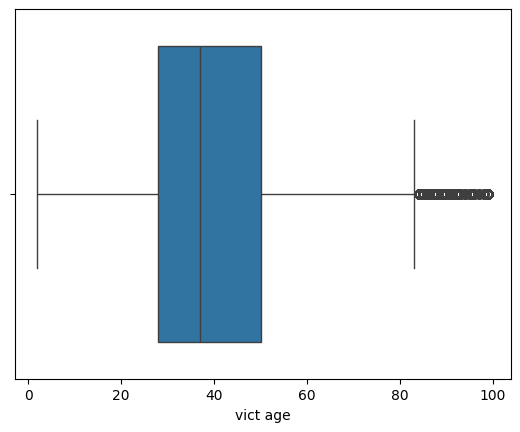

In [34]:
sns.boxplot(x=df['vict age'])
plt.show()

In [35]:
Q1 = df['vict age'].quantile(0.25)
Q3 = df['vict age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['vict age'] >= lower) & (df['vict age'] <= upper)]

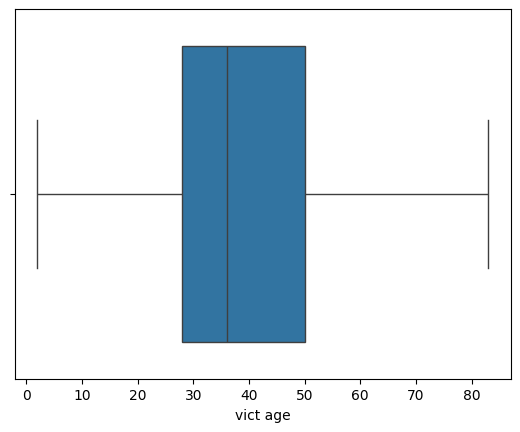

In [36]:
sns.boxplot(x=df['vict age'])
plt.show()

In [37]:
df['vict age'].describe()

count    729626.000000
mean         39.205788
std          15.134744
min           2.000000
25%          28.000000
50%          36.000000
75%          50.000000
max          83.000000
Name: vict age, dtype: float64

In [38]:
df['crm cd desc'].value_counts()

crm cd desc
BATTERY - SIMPLE ASSAULT                          73135
BURGLARY FROM VEHICLE                             61390
THEFT OF IDENTITY                                 60815
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT    51317
THEFT PLAIN - PETTY ($950 & UNDER)                46499
                                                  ...  
PETTY THEFT - AUTO REPAIR                             2
LYNCHING - ATTEMPTED                                  1
DISHONEST EMPLOYEE ATTEMPTED THEFT                    1
TRAIN WRECKING                                        1
DRUNK ROLL - ATTEMPT                                  1
Name: count, Length: 138, dtype: int64

In [41]:
crime_counts = df['crm cd desc'].value_counts()
valid_crimes = crime_counts[crime_counts >= 2000].index
df = df[df['crm cd desc'].isin(valid_crimes)]
print("Remaining Crime Types:", df['crm cd desc'].nunique())
print(df['crm cd desc'].value_counts())

Remaining Crime Types: 35
crm cd desc
BATTERY - SIMPLE ASSAULT                                    73135
BURGLARY FROM VEHICLE                                       61390
THEFT OF IDENTITY                                           60815
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              51317
THEFT PLAIN - PETTY ($950 & UNDER)                          46499
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     46113
INTIMATE PARTNER - SIMPLE ASSAULT                           45959
BURGLARY                                                    39075
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)         34971
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD    27381
ROBBERY                                                     25743
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                    19885
CRIMINAL THREATS - NO WEAPON DISPLAYED                      18544
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             16158
BRANDISH WEAPON                       

In [42]:
original_rows = df.shape[0]
print(original_rows)

693672


In [39]:
############ FEATURE ENGINEERING ##############

In [43]:
df['year'] = df['date occ'].dt.year
df['month'] = df['date occ'].dt.month
df['day'] = df['date occ'].dt.day
df['weekday'] = df['date occ'].dt.weekday

In [44]:
df['hour'] = df['time occ'] // 100

In [45]:
df['age_group'] = pd.cut(
    df['vict age'],
    bins=[0, 18, 30, 50, 100],
    labels=['Teen', 'Young', 'Adult', 'Senior']
)

In [46]:
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [47]:
df['time_category'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

In [48]:
df['age_group'].value_counts()

age_group
Adult     303026
Young     201447
Senior    165886
Teen       23313
Name: count, dtype: int64

In [49]:
area_freq = df['area name'].value_counts().to_dict()
df['area_crime_count'] = df['area name'].map(area_freq)

In [50]:
import joblib

area_freq = df['area name'].value_counts().to_dict()

joblib.dump(area_freq, "area_freq.pkl")

['area_freq.pkl']

In [51]:
df.drop(['day'], axis=1, inplace=True)

In [52]:
df.drop(['date occ', 'date rptd', 'time occ', 'location', 'cross street'], axis=1, inplace=True)

In [53]:
df.head()
df.columns

Index(['dr_no', 'area', 'area name', 'rpt dist no', 'part 1-2', 'crm cd',
       'crm cd desc', 'vict age', 'vict sex', 'vict descent', 'premis cd',
       'premis desc', 'weapon used cd', 'weapon desc', 'status', 'status desc',
       'lat', 'lon', 'year', 'month', 'weekday', 'hour', 'age_group',
       'is_weekend', 'time_category', 'area_crime_count'],
      dtype='object')

In [54]:
############ EXPLORATORY DATA ANALYSIS(EDA)  ##############

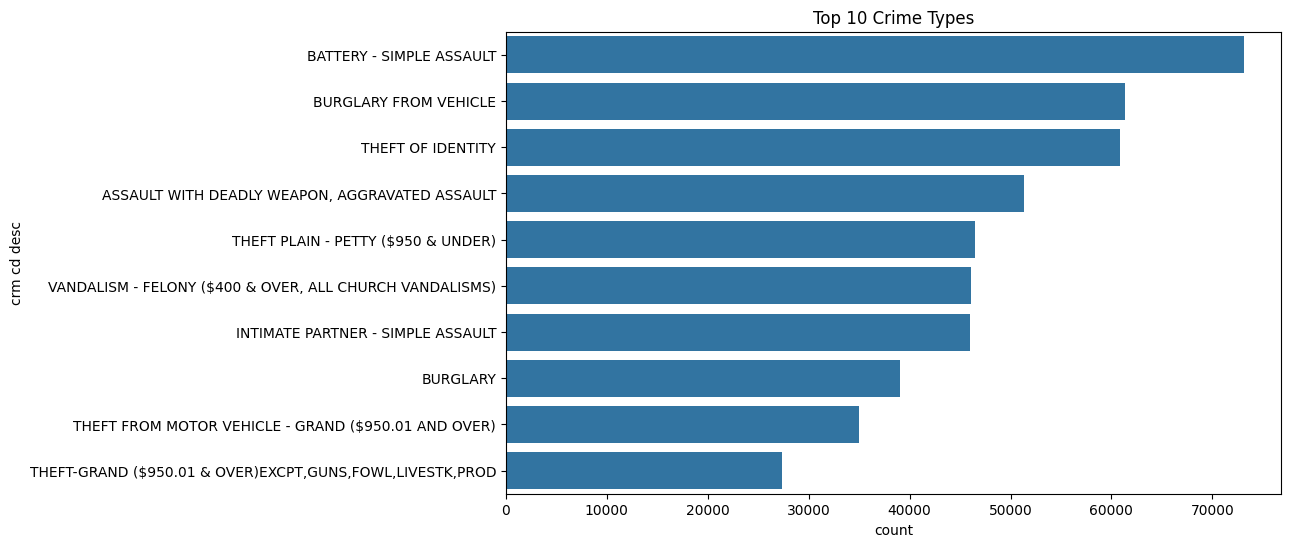

In [55]:
plt.figure(figsize=(10,6))
sns.countplot(
    y='crm cd desc',
    data=df,
    order=df['crm cd desc'].value_counts().index[:10]
)
plt.title("Top 10 Crime Types")
plt.show()

countplot() counts the number of records in each category.

It is the best visualization for frequency comparison.
    The graph shows the ten crime categories with the highest number of reported incidents.

From your graph,

The most common crimes include:

Battery - Simple Assault
Burglary from Vehicle
Theft of Identity
Aggravated Assault
Simple Assault is the most frequently reported crime.

Vehicle burglary and identity theft are also very common.

These crime types may require greater police attention.

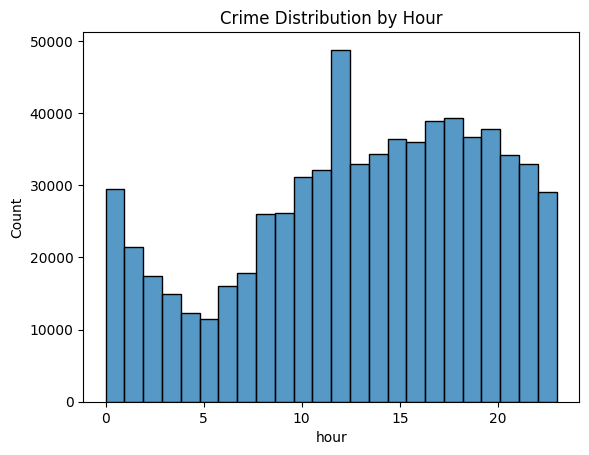

In [56]:
sns.histplot(df['hour'], bins=24)
plt.title("Crime Distribution by Hour")
plt.show()

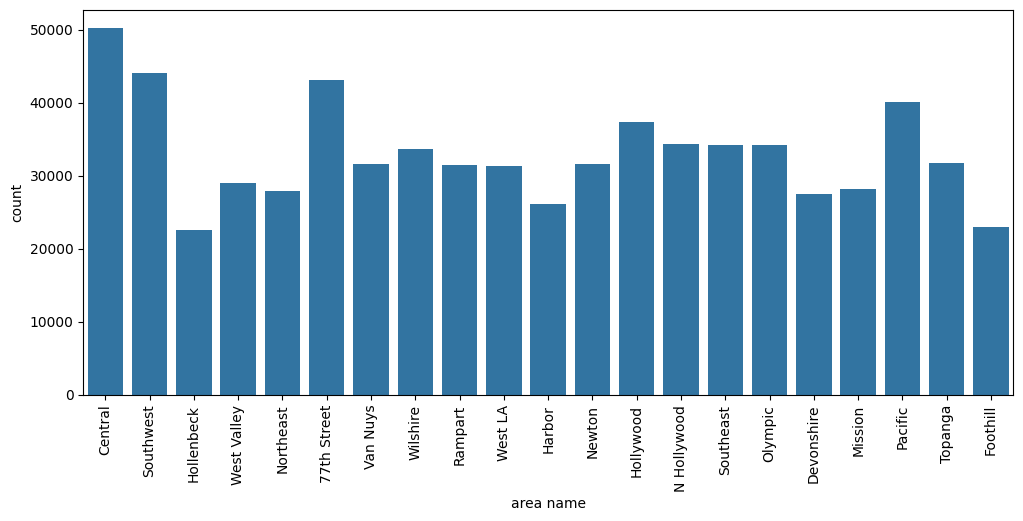

In [57]:
plt.figure(figsize=(12,5))
sns.countplot(x='area name', data=df)
plt.xticks(rotation=90)
plt.show()

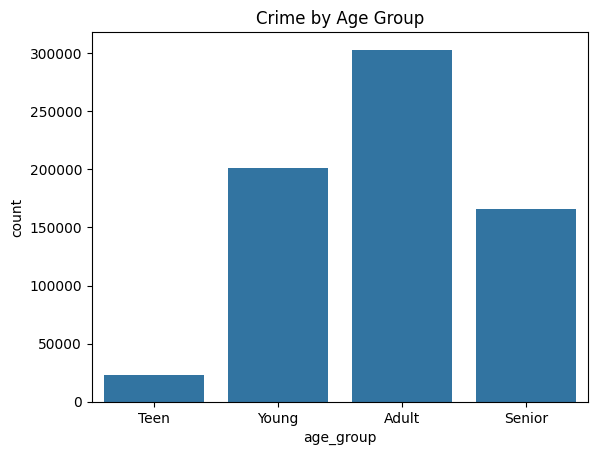

In [58]:
sns.countplot(x='age_group', data=df)
plt.title("Crime by Age Group")
plt.show()

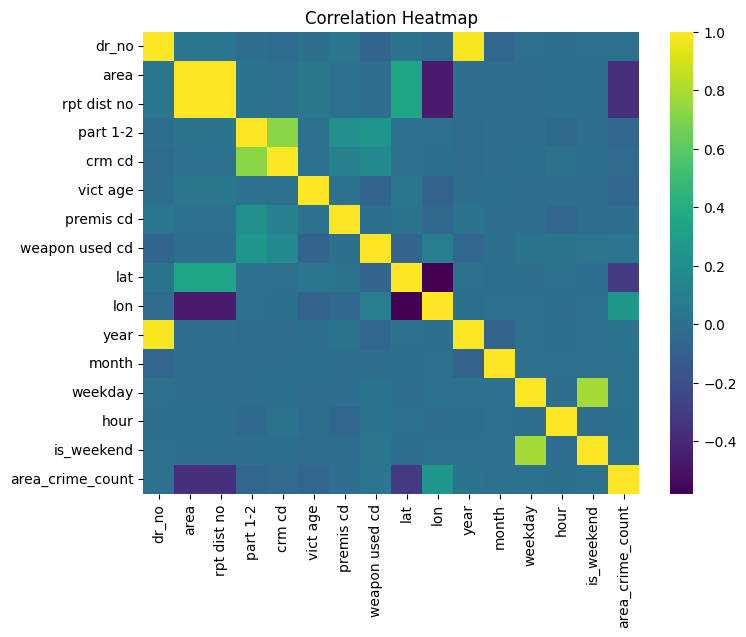

In [59]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='viridis',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [60]:
################ ENCODING #############

In [61]:
df.select_dtypes(include='object').columns

Index(['area name', 'crm cd desc', 'vict sex', 'vict descent', 'premis desc',
       'weapon desc', 'status', 'status desc'],
      dtype='object')

In [62]:
le = LabelEncoder()
for col in ['vict sex', 'vict descent', 'status desc']:
    df[col] = le.fit_transform(df[col])

In [63]:
df = pd.get_dummies(df, columns=['age_group', 'time_category'], drop_first=True)

In [64]:
df.to_csv("cleaned_crime data1.csv", index=False)

In [65]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in [
    'area name',
    'vict sex',
    'vict descent',
    'premis desc',
    'weapon desc',
    'status',
    'status desc'
]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [66]:
############### MODEL BUILDING ##############

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 693672 entries, 1 to 1005195
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dr_no                    693672 non-null  int64  
 1   area                     693672 non-null  int64  
 2   area name                693672 non-null  int64  
 3   rpt dist no              693672 non-null  int64  
 4   part 1-2                 693672 non-null  int64  
 5   crm cd                   693672 non-null  int64  
 6   crm cd desc              693672 non-null  object 
 7   vict age                 693672 non-null  int64  
 8   vict sex                 693672 non-null  int64  
 9   vict descent             693672 non-null  int64  
 10  premis cd                693672 non-null  float64
 11  premis desc              693672 non-null  int64  
 12  weapon used cd           693672 non-null  float64
 13  weapon desc              693672 non-null  int64  
 14  status  

In [68]:
df.columns

Index(['dr_no', 'area', 'area name', 'rpt dist no', 'part 1-2', 'crm cd',
       'crm cd desc', 'vict age', 'vict sex', 'vict descent', 'premis cd',
       'premis desc', 'weapon used cd', 'weapon desc', 'status', 'status desc',
       'lat', 'lon', 'year', 'month', 'weekday', 'hour', 'is_weekend',
       'area_crime_count', 'age_group_Young', 'age_group_Adult',
       'age_group_Senior', 'time_category_Morning', 'time_category_Afternoon',
       'time_category_Evening'],
      dtype='object')

In [69]:
[col for col in df.columns if 'crm' in col]

['crm cd', 'crm cd desc']

In [70]:
X = df.drop("crm cd desc", axis=1)
y = df["crm cd desc"]

In [71]:
print(X.columns.tolist())

['dr_no', 'area', 'area name', 'rpt dist no', 'part 1-2', 'crm cd', 'vict age', 'vict sex', 'vict descent', 'premis cd', 'premis desc', 'weapon used cd', 'weapon desc', 'status', 'status desc', 'lat', 'lon', 'year', 'month', 'weekday', 'hour', 'is_weekend', 'area_crime_count', 'age_group_Young', 'age_group_Adult', 'age_group_Senior', 'time_category_Morning', 'time_category_Afternoon', 'time_category_Evening']


In [72]:
le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [74]:
print(X.dtypes)

dr_no                        int64
area                         int64
area name                    int64
rpt dist no                  int64
part 1-2                     int64
crm cd                       int64
vict age                     int64
vict sex                     int64
vict descent                 int64
premis cd                  float64
premis desc                  int64
weapon used cd             float64
weapon desc                  int64
status                       int64
status desc                  int64
lat                        float64
lon                        float64
year                         int32
month                        int32
weekday                      int32
hour                         int64
is_weekend                   int64
area_crime_count             int64
age_group_Young               bool
age_group_Adult               bool
age_group_Senior              bool
time_category_Morning         bool
time_category_Afternoon       bool
time_category_Evenin

In [75]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [76]:
import joblib

joblib.dump(model, "crime_model.pkl", compress=3)

['crime_model.pkl']

In [77]:
import os

print(os.path.getsize("crime_model.pkl")/(1024*1024))

37.499722480773926


In [78]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9660792157710744


In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9660792157710744
Precision: 0.9665039520035377
Recall   : 0.9660792157710744
F1 Score : 0.9634379642567841


In [80]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     10330
           1       1.00      0.91      0.95       864
           2       1.00      1.00      1.00     14610
           3       0.89      0.94      0.92       809
           4       0.95      0.91      0.93      1597
           5       0.99      1.00      1.00      2895
           6       0.85      0.79      0.82      1151
           7       0.99      1.00      0.99      7806
           8       1.00      1.00      1.00     12300
           9       1.00      0.86      0.93       560
          10       0.97      0.98      0.97       723
          11       0.88      0.54      0.67       566
          12       0.96      0.96      0.96      3817
          13       0.99      0.33      0.50       451
          14       0.97      0.98      0.98      2526
          15       0.95      1.00      0.97      9203
          16       0.95      0.90      0.92      1587
          17       1.00    

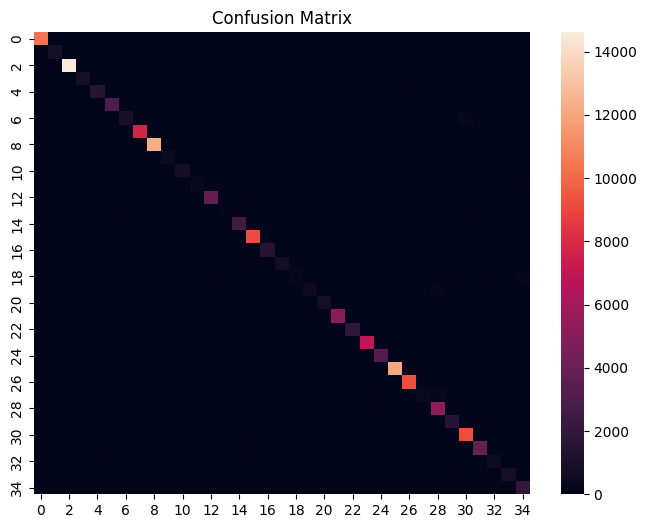

In [81]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

In [82]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance.head(10))

crm cd            0.564601
weapon used cd    0.094850
part 1-2          0.093502
weapon desc       0.075478
premis cd         0.051319
premis desc       0.030196
status desc       0.010698
status            0.010369
vict age          0.009532
vict sex          0.006869
dtype: float64


In [85]:
import joblib

joblib.dump(model, "crime_model.pkl")
joblib.dump(le_dict, "feature_encoders.pkl")
joblib.dump(le_target, "target_encoder.pkl")

print("Model saved successfully.")

Model saved successfully.


In [84]:
joblib.dump(model, "crime_model_small.pkl", compress=3)

['crime_model_small.pkl']